# Testing explainability with Xplique

In [3]:
!pip install xplique

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of xplique to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.4/191.4 kB 6.6 MB/s eta 0:00:00


## Imports

In [4]:
import numpy as np
import joblib
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline

from keras.utils import image_dataset_from_directory

from keras.applications.efficientnet import preprocess_input

from xplique.attributions import GradCAM

from xplique.features_visualizations import Objective
from xplique.features_visualizations import optimize

import tensorflow as tf
import cv2

2026-03-17 12:58:21.111276: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773752301.377152      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773752301.462399      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773752302.087075      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773752302.087136      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773752302.087139      55 computation_placer.cc:177] computation placer alr

## Model

In [284]:
cnn_model = joblib.load('/kaggle/input/models/tamlacroix/cnn-full-dataset/keras/default/1/cnn_full_dataset.joblib')
efficientnet_model = joblib.load('/kaggle/input/models/tamlacroix/efficientnet-full-dataset/keras/default/1/efficientnet_full_dataset.joblib')

In [611]:
MODEL_NAME = 'efficientnet'  #cnn or efficientnet

In [612]:
if MODEL_NAME == 'cnn':
    model = cnn_model
elif MODEL_NAME == 'efficientnet':
    model = efficientnet_model

## Loading image

In [613]:
# img_name = '00276TOPP4.jpg'
# # img_name = '008BYSE725.jpg'
# img_path = '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/fake/ZZA9QHUR78.jpg'

# img_path = '/kaggle/input/datasets/tamlacroix/pedro-image/image.png'
# img_path = '/kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1/test/fake/FAULKHNZJQ.jpg'
# img_path = '/kaggle/input/datasets/tamlacroix/image34/Image34.jpeg'

# img_path = '/kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1/test/fake/FCQ6L9VIY0.jpg'
# img_path = '/kaggle/input/datasets/tamlacroix/fake-image/Image trump casquette.png'
# img_path = '/kaggle/input/datasets/tamlacroix/tom-cruise-gpt/ChatGPT_Tom.png'
# img_path = '/kaggle/input/datasets/chelove4draste/25k-ai-generated-faces/25k/seed15904.png'

# img_path = '/kaggle/input/datasets/tamlacroix/fake-imgs-giving-real-in-cnn/Image45.jpeg'
# img_path = '/kaggle/input/datasets/tamlacroix/nightmare-girl/ZZQA8E7G26.jpg'
# img_path = '/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/fake/ZZQA8E7G26.jpg'
# img_path = '/kaggle/input/datasets/tamlacroix/image13/Image13.jpeg'

In [614]:
img_path = '/kaggle/input/datasets/tamlacroix/image13/Image13.jpeg'

In [615]:
img = Image.open(img_path)
img = img.resize((256, 256))
# img = np.expand_dims(img, axis=0)
# img.shape

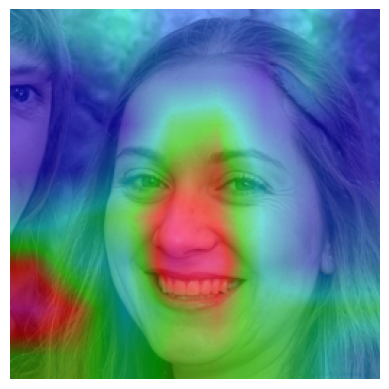

In [616]:
if MODEL_NAME == 'efficientnet': 
    # feature extractor (EfficientNet only)
    base_model = model.get_layer('efficientnetb3')
    
    # classifier head (everything AFTER EfficientNet)
    x = tf.keras.Input(shape=base_model.output.shape[1:])
    y = x
    for layer in model.layers[2:]:  # skip input + efficientnet
        y = layer(y)
    
    classifier_head = tf.keras.Model(x, y)
    
    def compute_gradcam(model, base_model, classifier_head, img):
        img = tf.cast(img, tf.float32)
        img = tf.expand_dims(img, axis=0)
    
        with tf.GradientTape() as tape:
            # forward pass through EfficientNet
            conv_outputs = base_model(img)
    
            # watch feature maps
            tape.watch(conv_outputs)
    
            # forward through classifier
            predictions = classifier_head(conv_outputs)
    
            # binary output
            loss = predictions[:, 0]
    
        # gradients w.r.t feature maps
        grads = tape.gradient(loss, conv_outputs)
    
        # Grad-CAM
        weights = tf.reduce_mean(grads, axis=(1, 2))
        cam = tf.reduce_sum(weights[:, None, None, :] * conv_outputs, axis=-1)
    
        cam = tf.nn.relu(cam)
        cam = cam[0] / (tf.reduce_max(cam) + 1e-8)
    
        return cam.numpy()
    
    heatmap = compute_gradcam(model, base_model, classifier_head, img)


    def resize_heatmap(heatmap, target_size=(256, 256)):
        return cv2.resize(heatmap, target_size)
    
    img = np.array(img)
    
    def overlay_heatmap(img, heatmap, alpha=0.5):
        # resize heatmap
        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
        # convert to 0–255
        heatmap = np.uint8(255 * heatmap)
    
        # apply colormap
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_RAINBOW)
    
        # ensure image is uint8 for display
        if img.dtype != np.uint8:
            img = img.astype(np.uint8)
    
        overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    
        return overlay
    
    overlay = overlay_heatmap(img, heatmap)
    
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

In [617]:
if MODEL_NAME == 'cnn':
    img = np.expand_dims(img, axis=0)
    #Generate explanations
    explainer = GradCAM(model)
    explanations = explainer(img, [[1, 0]]) 
    overlay = explanations[0]

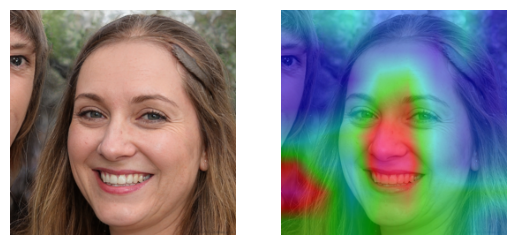

In [618]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(np.squeeze(img))
ax[0].axis('off')
ax[1].imshow(np.squeeze(img))
if MODEL_NAME == 'cnn':
    ALPHA = 0.5
elif MODEL_NAME == 'efficientnet':
    ALPHA = 1
ax[1].imshow(overlay, cmap="jet", alpha=ALPHA)
ax[1].axis('off');

In [619]:
# fig, ax = plt.subplots(1, 2)
# ax[0].imshow(np.squeeze(img))
# ax[0].axis('off')
# ax[1].imshow(np.squeeze(img))
# ax[1].imshow(explanations[0], cmap="jet", alpha=0.5)
# ax[1].axis('off');

In [620]:
if MODEL_NAME == 'efficientnet':
    img = np.expand_dims(img, axis=0)

In [621]:
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step


array([[0.31958196]], dtype=float32)

In [622]:
# # new_test_data_dir = '/kaggle/input/datasets/chelove4draste/25k-ai-generated-faces/25k/'

# new_test_data_dir = '/kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1/test/fake/'
 
# from pathlib import Path

# predictions = []
# directory = Path(new_test_data_dir) 
# for item in directory.iterdir():
#     if item.is_file():
#         print(item.name)
#         img = Image.open(item)
#         img = img.resize((256, 256))
#         img = np.expand_dims(img, axis=0)
#         predictions += [model.predict(img, verbose=0)[0][0]]

# # predictions = []
# # for i in range(10,100):
# #     # print(i)
# #     img = Image.open(new_test_data_dir+f"seed159{i}.png")
# #     img = img.resize((256, 256))
# #     img = np.expand_dims(img, axis=0)
# #     predictions += [model.predict(img, verbose=0)[0][0]]

# predictions = np.array(predictions)

In [623]:
# predictions = np.array(predictions)
# len(predictions[predictions<=0.5])

In [624]:
# predictions